In [3]:
import numpy as np
import pandas as pd
from sys import stderr
from numpy import zeros, arange, isscalar,diag, dot,eye, ix_, ones, r_, pi, flatnonzero as find
from scipy.sparse import csr_matrix as sparse
from numpy.linalg import solve
from dask import delayed, compute
from dask.distributed import Client
import pickle
import time
import seaborn as sns
import matplotlib.pyplot as plt
import pyomo.environ as pyo

BUS_TYPE = 1
REF = 3
BUS_I = 0
F_BUS = 1
T_BUS = 2
BR_X = 4
TAP = 9
SHIFT = 10
BR_STATUS = 12

if "client" not in globals():
    client = Client(n_workers=8, threads_per_worker=1, processes=True)

In [4]:
# multivariate normal
def create_scenario_multivariate(case, model, N, sigma_scaling = 0.03):
    buses = case['bus'].values
    baseMVA = case['baseMVA']['baseMVA'][0]
    # buses_cols = {col:num for num,col in enumerate(case.bus.columns.values)}
    base_demand = case['bus'].Pd.values / baseMVA
    # base_demand = buses[:,buses_cols['PD']] / case.baseMVA
    sigma = (sigma_scaling * base_demand)
    mean = np.zeros(len(base_demand))
    covariance_matrix = np.diag(sigma**2)
    omega = np.random.multivariate_normal(mean, covariance_matrix, N)
    return omega

# uniform
def create_scenario_uniform(case, model, percentage, N):
    buses = case.bus.values
    buses_cols = {col:num for num,col in enumerate(case['bus'].columns.values)}
    base_demand = buses[:,buses_cols['PD']] / case.baseMVA
    demand_test = {}
    for i in range(N):
        demand_list = []
        for d in base_demand:
            dev = np.random.uniform(-percentage,percentage)
            demand_list.append(d * dev)
        demand_test[i] = demand_list
    return demand_test

def update_injection_constraints(case, model, omega_bound):
    omega = case['omega']
    omega.LB = omega_bound
    omega.UB = omega_bound
    model.update()  # Update the model to reflect these changes
                
def makeBdc(baseMVA, bus, branch):
    """Builds the B matrices and phase shift injections for DC power flow.

    Returns the B matrices and phase shift injection vectors needed for a
    DC power flow.
    The bus real power injections are related to bus voltage angles by::
        P = Bbus * Va + PBusinj
    The real power flows at the from end the lines are related to the bus
    voltage angles by::
        Pf = Bf * Va + Pfinj
    Does appropriate conversions to p.u.
    @see: L{dcpf}
    @author: Carlos E. Murillo-Sanchez (PSERC Cornell & Universidad
    Autonoma de Manizales)
    @author: Ray Zimmerman (PSERC Cornell)
    """
    ## constants
    nb = bus.shape[0]          ## number of buses
    nl = branch.shape[0]       ## number of lines

    ## check that bus numbers are equal to indices to bus (one set of bus nums)
    if any(bus[:, BUS_I]-1 != list(range(nb))):
        stderr.write('makeBdc: buses must be numbered consecutively in '
                     'bus matrix\n')

    ## for each branch, compute the elements of the branch B matrix and the phase
    ## shift "quiescent" injections, where
    ##
    ##      | Pf |   | Bff  Bft |   | Vaf |   | Pfinj |
    ##      |    | = |          | * |     | + |       |
    ##      | Pt |   | Btf  Btt |   | Vat |   | Ptinj |
    ##
    stat = branch[:, BR_STATUS]               ## ones at in-service branches
    b = stat / branch[:, BR_X]                ## series susceptance
    tap = ones(nl)                            ## default tap ratio = 1
    i = find(branch[:, TAP])               ## indices of non-zero tap ratios
    tap[i] = branch[i, TAP]                   ## assign non-zero tap ratios
    b = b / tap

    ## build connection matrix Cft = Cf - Ct for line and from - to buses
    f = branch[:, F_BUS] -1                           ## list of "from" buses
    t = branch[:, T_BUS] -1                          ## list of "to" buses
    i = r_[range(nl), range(nl)]                   ## double set of row indices
    ## connection matrix
    Cft = sparse((r_[ones(nl), -ones(nl)], (i, r_[f, t])), (nl, nb))

    ## build Bf such that Bf * Va is the vector of real branch powers injected
    ## at each branch's "from" bus
    Bf = sparse((r_[b, -b], (i, r_[f, t])), shape = (nl, nb))## = spdiags(b, 0, nl, nl) * Cft

    ## build Bbus
    Bbus = Cft.T * Bf

    ## build phase shift injection vectors
    Pfinj = b * (-branch[:, SHIFT] * pi / 180)  ## injected at the from bus ...
    # Ptinj = -Pfinj                            ## and extracted at the to bus
    Pbusinj = Cft.T * Pfinj                ## Pbusinj = Cf * Pfinj + Ct * Ptinj

    return Bbus, Bf, Pbusinj, Pfinj

def makePTDF(baseMVA, bus, branch, slack=None):
    """Builds the DC PTDF matrix for a given choice of slack.

    Returns the DC PTDF matrix for a given choice of slack. The matrix is
    C{nbr x nb}, where C{nbr} is the number of branches and C{nb} is the
    number of buses. The C{slack} can be a scalar (single slack bus) or an
    C{nb x 1} column vector of weights specifying the proportion of the
    slack taken up at each bus. If the C{slack} is not specified the
    reference bus is used by default.

    For convenience, C{slack} can also be an C{nb x nb} matrix, where each
    column specifies how the slack should be handled for injections
    at that bus.

    @see: L{makeLODF}

    @author: Ray Zimmerman (PSERC Cornell)
    """
    ## use reference bus for slack by default
    if slack is None:
        slack = find(bus[:, BUS_TYPE] == REF)
        slack = slack[0]

    ## set the slack bus to be used to compute initial PTDF
    if isscalar(slack):
        slack_bus = slack
    else:
        slack_bus = 0      ## use bus 1 for temp slack bus

    nb = bus.shape[0]
    nbr = branch.shape[0]
    noref = arange(1, nb)      ## use bus 1 for voltage angle reference
    noslack = find(arange(nb) != slack_bus)

    ## check that bus numbers are equal to indices to bus (one set of bus numbers)
    if any(bus[:, BUS_I]-1 != arange(nb)):
        stderr.write('makePTDF: buses must be numbered consecutively')

    ## compute PTDF for single slack_bus
    Bbus, Bf, _, _ = makeBdc(baseMVA, bus, branch)
    Bbus, Bf = Bbus.todense(), Bf.todense()
    H = zeros((nbr, nb))
    H[:, noslack] = solve( Bbus[ix_(noslack, noref)].T, Bf[:, noref].T ).T
    #             = Bf[:, noref] * inv(Bbus[ix_(noslack, noref)])

    ## distribute slack, if requested
    if not isscalar(slack):
        if len(slack.shape) == 1:  ## slack is a vector of weights
            slack = slack / sum(slack)   ## normalize weights

            ## conceptually, we want to do ...
            ##    H = H * (eye(nb, nb) - slack * ones((1, nb)))
            ## ... we just do it more efficiently
            v = dot(H, slack)
            for k in range(nb):
                H[:, k] = H[:, k] - v
        else:
            H = dot(H, slack)

    return H                

def makeLODF(branch, PTDF):
    nl, nb = PTDF.shape
    f = branch[:, F_BUS].astype(int)-1
    t = branch[:, T_BUS].astype(int)-1
    Cft = sparse((r_[ones(nl), -ones(nl)],
                      (r_[f, t], r_[arange(nl), arange(nl)])), (nb, nl))

    H = PTDF * Cft
    h = diag(H, 0)
    LODF = H / (ones((nl, nl)) - ones((nl, 1)) * h.T)
    LODF = LODF - diag(diag(LODF)) - eye(nl, nl)
    # if there's a radial outage
    LODF[np.isinf(LODF)] = 0.0
    LODF[np.isnan(LODF)] = 0.0
    np.fill_diagonal(LODF, -1)

    return LODF

def islanding_line_indices(branch, PTDF, tol=1e-9):
    # replicate the pieces in makeLODF up to h
    nl, nb = PTDF.shape
    f = branch[:, F_BUS].astype(int) - 1
    t = branch[:, T_BUS].astype(int) - 1

    # sparse incidence Cft (nb x nl)
    from numpy import arange, r_, ones
    Cft = sparse(
        (r_[ones(nl), -ones(nl)],
         (r_[f, t], r_[arange(nl), arange(nl)])),
        shape=(nb, nl)
    )

    H = PTDF @ Cft          # (nl x nl)
    h = np.diag(H)          # length nl
    denom = 1.0 - h         # per-line denominator in LODF formula

    # islanding iff 1 - h[k] ~ 0
    mask_islanding = np.isclose(denom, 0.0, atol=tol)
    idx_islanding = np.where(mask_islanding)[0]
    return idx_islanding

In [ ]:
# === Initialization ===
case_name = 'pglib_opf_case30_fsr'
case_path = f'../excel_outputs/{case_name}.xlsx'
case = pd.read_excel(case_path, sheet_name=['baseMVA','bus','gen','gencost','branch'])
bus_to_idx = {bus: i+1 for i, bus in enumerate(case['bus'].bus_i.values)}
bus_idx = [bus_to_idx[bus] for bus in case['bus'].bus_i.values]
case['bus'].bus_i = case['bus'].bus_i.replace(bus_to_idx) # rename the bus for making PTDF
case['gen'].bus_i = case['gen'].bus_i.replace(bus_to_idx)
baseMVA = case['baseMVA']['baseMVA'][0]
# remove generators and costgen with pmax and pmin equal to zero
zero_gen_idx = []
for num,i in enumerate(case['gen'].Pmax.values/ baseMVA):
    if (i == 0 and (case['gen'].Pmin.values / baseMVA)[num] == 0) or (case['gen'].Pmin.values / baseMVA)[num] < 0:
        zero_gen_idx.append(num)
case['gen'].drop(index=zero_gen_idx, inplace=True) # drop
case['gencost'].drop(index=zero_gen_idx, inplace=True) # drop
pmax = case['gen'].Pmax.values / baseMVA
pmin = case['gen'].Pmin.values / baseMVA
case['branch'].bus_i = case['branch'].bus_i.replace(bus_to_idx)
case['branch'].bus_j = case['branch'].bus_j.replace(bus_to_idx)
case['K'] = makePTDF(baseMVA, case['bus'].values, case['branch'].values, slack=None)
case['L'] = makeLODF(case['branch'].values, case['K']) # makeLODF(branch, PTDF)

# case['L'] = makeLODF(case['branch'].values, case['K']) # makeLODF(branch, PTDF)
nbus = case['bus'].shape[0]
ngen = case['gen'].shape[0]
nbranch = case['branch'].shape[0]
case['B'] = np.zeros((nbus,ngen))
for gen,bus in enumerate(case['gen'].bus_i.values): #case['gen'].bus_i
    case['B'][int(bus)-1][gen] = 1    
case['gamma'] = 0.05 # An exact and scalable problem decomposition for security-constrained optimal power flow: We performed simulations for various values of γ, β1, and β2. Our results indicate that varying the parameters may impact the perfor￾mance of the CCGA. However, the dominance of the CCGA over other methods (EF and BDDC) was a constant, despite the parameterization. We have reported results for β1 = 5, β2 = 1.2, and γi = 0.05 for all i ∈ 𝒢.
d = case['bus'].Pd.values/baseMVA

# case['Kg'] = [10,11]
case['Kg'] = range(ngen)
case['Ke'] = islanding_line_indices(case['branch'].values, case['K'], tol=1e-9)
case['M_eta'] = 1500 # Self-Supervised Learning for Large-Scale Preventive Security Constrained DC Optimal Power Flow
case['rho_ADMM'] = 1_0
case_fut = client.scatter(case, broadcast=True)
print(case)

C:\Users\firda\AppData\Local\Temp\ipykernel_16436\970346129.py:164: RuntimeWarning: divide by zero encountered in divide
  LODF = H / (ones((nl, nl)) - ones((nl, 1)) * h.T)
C:\Users\firda\AppData\Local\Temp\ipykernel_16436\970346129.py:164: RuntimeWarning: invalid value encountered in divide
  LODF = H / (ones((nl, nl)) - ones((nl, 1)) * h.T)
C:\Users\firda\AppData\Local\Temp\ipykernel_16436\970346129.py:165: RuntimeWarning: invalid value encountered in subtract
  LODF = LODF - diag(diag(LODF)) - eye(nl, nl)


{'baseMVA':    baseMVA
0      100, 'bus':     bus_i  type    Pd    Qd  Gs    Bs  area     Vm  Va  baseKV  zone  Vmax  \
0       1     3   0.0   0.0   0  0.00     1  1.000   0     135     1  1.05   
1       2     2  21.7  12.7   0  0.00     1  1.025   0     135     1  1.10   
2       3     1   2.4   1.2   0  0.00     1  1.000   0     135     1  1.05   
3       4     1   7.6   1.6   0  0.00     1  1.000   0     135     1  1.05   
4       5     1   0.0   0.0   0  0.19     1  1.000   0     135     1  1.05   
5       6     1   0.0   0.0   0  0.00     1  1.000   0     135     1  1.05   
6       7     1  22.8  10.9   0  0.00     1  1.000   0     135     1  1.05   
7       8     1  30.0  30.0   0  0.00     1  1.000   0     135     1  1.05   
8       9     1   0.0   0.0   0  0.00     1  1.000   0     135     1  1.05   
9      10     1   5.8   2.0   0  0.00     3  1.000   0     135     1  1.05   
10     11     1   0.0   0.0   0  0.00     1  1.000   0     135     1  1.05   
11     12     1  11.2 

In [6]:
def ADMM1(case):
    """
    Build Pyomo model for Q1 based on provided `case` dict.
    Returns: ConcreteModel
    """
    # read shapes
    nbus = case['bus'].shape[0]
    ngen = case['gen'].shape[0]
    nbranch = case['branch'].shape[0]
    Kg = list(case['Kg']) if 'Kg' in case else list(range(ngen))
    Ke = list(case['Ke']) if 'Ke' in case else []

    K = np.array(case['K'])               # shape (nbranch, nbus)
    B = np.array(case['B'])               # shape (nbus, ngen)
    L  = np.array(case['L'])
    baseMVA = case['baseMVA']['baseMVA'][0]
    d = np.array(case['bus'].Pd.values / baseMVA).flatten()  # length nbus
    pmax = np.array(case['gen'].Pmax.values / baseMVA).flatten()
    pmin = np.array(case['gen'].Pmin.values / baseMVA).flatten()
    limit = np.array(case['branch'].rateA.values / baseMVA).flatten()
    M_eta = float(case.get('M_eta', 0.0))

    # gencost linear coeffs for objective (using same pattern as your code)
    gencost = np.array(case['gencost'][['c2', 'c1', 'c0']].values)
    # Build linear objective coefficients vector (as in your code)
    obj_coeff = (gencost[:, 0] * baseMVA**2 + gencost[:, 1] * baseMVA + gencost[:, 2]).flatten()

    model = pyo.ConcreteModel(name="Q1_pyomo")

    model.G = pyo.RangeSet(0, ngen-1)
    model.N = pyo.RangeSet(0, nbus-1)
    model.BR = pyo.RangeSet(0, nbranch-1)
    model.Ke = pyo.Set(initialize=Ke)
    model.eta_ke_index = pyo.Set(initialize=[(k,b) for k in Ke for b in model.BR])
    model.gk_index = pyo.Set(initialize=[(k,i) for k in Kg for i in model.G])

    model.g = pyo.Var(model.G, domain=pyo.NonNegativeReals)                       # generator outputs
    model.eta0 = pyo.Var(model.BR, domain=pyo.NonNegativeReals)                    # slack on branch limits (base)
    model.eta_ke = pyo.Var(model.eta_ke_index, domain=pyo.NonNegativeReals)
    
    model.omega = pyo.Param(model.N, initialize=0.0, mutable=True)  
    # model.u = pyo.Param(model.G,  initialize={i: np.random.normal(0,1) for i in model.G},    mutable=True)     # can be fixed later externally
    # model.xi = pyo.Param(model.G, initialize={i: np.random.normal(0,1) for i in model.G},    mutable=True)
    model.u = pyo.Param(model.gk_index,  initialize={(k,i): 0 for k in Kg for i in model.G},mutable=True)     # can be fixed later externally
    model.xi = pyo.Param(model.gk_index,  initialize={(k,i): 0 for k in Kg for i in model.G},mutable=True)     # can be fixed later externally
    model.rho_ADMM = pyo.Param(initialize=case['rho_ADMM'], mutable=True)  
    model.M_eta = pyo.Param(initialize=M_eta, mutable=True)  
    
    model.obj = pyo.ObjectiveList()
    # (59)
    model.obj.add( 

    expr =
    1/(ngen+1)*sum(obj_coeff[i] * model.g[i] for i in model.G)
    + model.M_eta * ( sum(model.eta0[b] for b in model.BR)
                      + sum(model.eta_ke[k,b] for (k,b) in model.eta_ke_index) )
    + 0.5 * model.rho_ADMM * sum((model.g[i] - model.xi[k,i] + model.u[k,i])**2 for k in Kg for i in model.G)
,        
    sense=pyo.minimize
)    
    
    model.balance = pyo.ConstraintList() 
    # (60)
    model.balance.add(
        sum(model.g[i] for i in model.G) == float(np.sum(d)) + sum(model.omega[n] for n in model.N)
    )

    def inj_expr(model, n):
        return d[n] + (model.omega[n] if n in model.N else 0.0) - sum(B[n,gg] * model.g[gg] for gg in model.G)
    model.inj = pyo.Expression(model.N, rule=inj_expr)
    
    def flow_expr(model, b):
        return sum(K[b,n] * model.inj[n] for n in model.N)
    model.flow = pyo.Expression(model.BR, rule=flow_expr) 
    
    model.branch_upper = pyo.ConstraintList()
    model.branch_lower = pyo.ConstraintList()
    # (61)
    for b in model.BR: 
        model.branch_upper.add(
            model.flow[b] <= float(limit[b]) + model.eta0[b]
        )
        model.branch_lower.add(
            model.flow[b] >= -float(limit[b]) - model.eta0[b]  
        )
    
    model.gen_ub = pyo.ConstraintList()
    model.gen_lb = pyo.ConstraintList() 
    # (62)
    for i in model.G: 
        model.gen_ub.add(
            model.g[i] <= float(pmax[i])
        )
        model.gen_lb.add(
            model.g[i] >= float(pmin[i])
        )
    
    def flow_expr_k(model, k, b):
        return model.flow[k] if k != b else 0
    model.flow_k = pyo.Expression(model.Ke, model.BR, rule=flow_expr_k) 
    
    model.line_upper = pyo.ConstraintList()
    model.line_lower = pyo.ConstraintList()
    # (63)
    for k in model.Ke:
        for b in model.BR:
            model.line_upper.add(
                model.flow[b] + model.flow_k[k,b]*L[b,k] <= float(limit[b]) + model.eta_ke[k,b]
            )
            model.line_lower.add(
                model.flow[b] + model.flow_k[k,b]*L[b,k] >= -float(limit[b]) - model.eta_ke[k,b]
            )

    return model
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++

def ADMM2_k(case, k):
    """
    Build Pyomo model for Q2 based on provided `case` dict.
    Returns: ConcreteModel
    """
 # read shapes
    nbus = case['bus'].shape[0]
    ngen = case['gen'].shape[0]
    nbranch = case['branch'].shape[0]
    # Kg = list(case['Kg']) if 'Kg' in case else list(range(ngen))
    # Ke = list(case['Ke']) if 'Ke' in case else []

    K = np.array(case['K'])               # shape (nbranch, nbus)
    B = np.array(case['B'])               # shape (nbus, ngen)
    # L  = np.array(case['L'])
    
    baseMVA = case['baseMVA']['baseMVA'][0]
    d = np.array(case['bus'].Pd.values / baseMVA).flatten()  # length nbus
    pmax = np.array(case['gen'].Pmax.values / baseMVA).flatten()
    pmin = np.array(case['gen'].Pmin.values / baseMVA).flatten()
    limit = np.array(case['branch'].rateA.values / baseMVA).flatten()
    M_eta = float(case.get('M_eta', 0.0))

    # gencost linear coeffs for objective (using same pattern as your code)
    gencost = np.array(case['gencost'][['c2', 'c1', 'c0']].values)
    # Build linear objective coefficients vector (as in your code)
    obj_coeff = (gencost[:, 0] * baseMVA**2 + gencost[:, 1] * baseMVA + gencost[:, 2]).flatten()

    model = pyo.ConcreteModel(name="Q2_pyomo")

    model.G = pyo.RangeSet(0, ngen-1)
    model.N = pyo.RangeSet(0, nbus-1)
    model.BR = pyo.RangeSet(0, nbranch-1)
    # model.Kg = pyo.Set(initialize=Kg)
    model.K = pyo.Set(initialize=[k])
    model.gk_index = pyo.Set(initialize=[(k,i) for i in model.G])
    model.eta_kg_index = pyo.Set(initialize=[(k,b) for b in model.BR])
    
    model.eta_kg = pyo.Var(model.eta_kg_index, domain=pyo.NonNegativeReals)
    model.xi = pyo.Var(model.gk_index, domain=pyo.NonNegativeReals)                      
    model.gk = pyo.Var(model.gk_index, domain=pyo.NonNegativeReals)
    # model.xk = pyo.Var(model.gk_index, domain=pyo.NonNegativeReals, bounds=(0,1))
    model.xk = pyo.Var(model.gk_index, domain=pyo.Binary)
    model.zk = pyo.Var(domain = pyo.NonNegativeReals, bounds=(0,1))
    
    model.omega = pyo.Param(model.N, initialize=0.0, mutable=True)  
    model.u = pyo.Param(model.G,  initialize={i: np.random.normal(0,1) for i in model.G},    mutable=True)     # can be fixed later externally
    model.zg = pyo.Param(model.G, initialize={i: np.random.normal(0,1) for i in model.G},    mutable=True)
    model.rho_ADMM = pyo.Param(initialize=case['rho_ADMM'], mutable=True)  
    model.M_eta = pyo.Param(initialize=M_eta, mutable=True)  

    model.obj = pyo.ObjectiveList()
    # (65)
    model.obj.add(
    expr =
    1/(ngen+1)*sum(obj_coeff[i] * model.xi[k,i] for i in model.G if i!=k)
    + model.M_eta * sum(model.eta_kg[k,b] for (k,b) in model.eta_kg_index)
    # + 0.5 * model.rho_ADMM * sum((model.zg[i] + model.u[i])**2 for i in model.G)
    + 0.5 * model.rho_ADMM * sum((model.zg[i] - model.xi[k,i] + model.u[i])**2 for i in model.G)
    # +       sum(model.u[i] * (model.xi[k,i] - model.zg[i]) for i in model.G)
,
    # expr= 0.5*(
    # sum(obj_coeff[i] * model.xi[k,i] for i in model.G)
    #     + model.M_eta * ( sum(model.eta_kg[k,b] for (k,b) in model.eta_kg_index) )
    #     + 0.5 * model.rho_ADMM * sum( (model.zg[i] - model.xi[k,i] + model.u[i])**2 for i in model.G )
    #     + 0.5 * sum(model.u[i] * (-model.xi[k,i]) for i in model.G)
    #     ),
    sense=pyo.minimize
)    
    
    model.balance_k = pyo.ConstraintList()
    model.balance_xi_k = pyo.ConstraintList()
    model.balance_k.add(
        sum(model.gk[k,i] for i in model.G if (k,i) in model.gk_index) 
                    == float(np.sum(d)) + sum(model.omega[n] for n in model.N)
    )    
    # model.balance_xi_k.add(
    #     sum(model.xi[k,i] for i in model.G if (k,i) in model.gk_index) 
    #                 == float(np.sum(d)) + sum(model.omega[n] for n in model.N)
    # )    

    def inj_k_expr(model, k, n):
        return d[n] + model.omega[n] - sum(B[n,gg] * model.gk[k,gg] for gg in model.G)
    model.inj_k = pyo.Expression(model.K, model.N, rule=inj_k_expr)
    def flow_expr_k(model, k, b):
        return sum(K[b,n] * model.inj_k[k,n] for n in model.N)
    model.flow_k = pyo.Expression(model.K, model.BR, rule=flow_expr_k) 
    model.fk_upper = pyo.ConstraintList()
    model.fk_lower = pyo.ConstraintList()
    for b in model.BR:
        model.fk_upper.add(
            model.flow_k[k,b] <= float(limit[b]) + model.eta_kg[k,b]
        )
        model.fk_lower.add(
            model.flow_k[k,b] >= -float(limit[b]) - model.eta_kg[k,b] 
        )
    
    model.gk_ub = pyo.ConstraintList()  
    model.gk_lb = pyo.ConstraintList()
    model.gk_fx = pyo.ConstraintList()
    for i in model.G:
        if i != k:
            model.gk_ub.add(
                model.gk[k,i] <= float(pmax[i])
            )
            model.gk_lb.add(
                model.gk[k,i] >= float(pmin[i])
            )
        else:
            model.gk_fx.add( # (69)
                model.gk[k,i] == 0.0
            )          

    model.c1 = pyo.ConstraintList()
    model.c2 = pyo.ConstraintList()
    model.c3 = pyo.ConstraintList()
    model.c4 = pyo.ConstraintList()
    # model.c5 = pyo.ConstraintList()
    model.c6 = pyo.ConstraintList()
    model.c7 = pyo.ConstraintList()
    model.c8 = pyo.ConstraintList()
    model.c9 = pyo.ConstraintList()
    
    gamma = case['gamma']
    gcap = pmax - pmin
    for i in model.G:
        if i != k:
            model.c1.add( # (70)
                model.gk[k,i] - model.xi[k,i] - model.zk*gamma*gcap[i] <= pmax[i]*(1-model.xk[k,i])
            )
            model.c2.add( # (71)
                -pmax[i]*(1-model.xk[k,i]) <= model.gk[k,i] - model.xi[k,i] - model.zk*gamma*gcap[i]
            )
            model.c3.add( # (72)
                model.xi[k,i] + model.zk*gamma*gcap[i] >= pmax[i]*(1-model.xk[k,i])
            )
            model.c4.add( # (73)
                model.gk[k,i] >= pmax[i] * (1 - model.xk[k,i])
            )
            # model.c5.add( # (74)
            #     (1 - model.zk[k]*gamma)*(model.ghat[i]-pmin[i]) - model.gk[k,i] <= -pmin[i] - model.zk[k]*gamma*gcap[i]
            # )
            # model.c6.add( # (75)
            #     model.gk[k,i] - model.xi[k,i] - model.zk[k]*gamma*gcap[i] + pmax[i] >= 0
            # )
            # model.c7.add( # (76)
            #     model.gk[k,i] <= 2*(model.xi[k,i] + model.zk[k]*gamma*gcap[i])
            # )    
            # model.c8.add( # (77)
            #     model.gk[k,i] >= 0.5 * (model.xi[k,i] + model.zk[k]*gamma*gcap[i])
            # )    
            # model.c9.add( # (78)
            #     model.gk[k,i] >= (1 - model.zk[k]*gamma)*pmin[i] + model.zk[k]*gamma*pmax[i]
            # )    

    # model.gen_ub = pyo.ConstraintList()
    # model.gen_lb = pyo.ConstraintList() 
    # for i in model.G: # (79)
    #     model.gen_ub.add(
    #         model.xi[k,i] <= float(pmax[i])
    #     )
    #     model.gen_lb.add(
    #         model.xi[k,i] >= float(pmin[i])
    #     )        
       
    return model

In [7]:
_MODEL_CACHE = {}

def solve_one_k(case, k, zg_vals, uk_vals):
    # key can include any case identifier + k
    key = ('ADMM2_k', k)
    if key not in _MODEL_CACHE:
        _MODEL_CACHE[key] = ADMM2_k(case, k)   # build once in this process
    
    model = _MODEL_CACHE[key]    
    # t0 = time.time()
    # model = ADMM2_k(case, k)
    # build_time = time.time() - t0    

    # set zg and u as before (mutate model in-place)
    for i, val in zg_vals.items():
        model.zg[i].set_value(float(val))

    # # set worker-specific u (u_vec is array-like, indexed by generator i)
    for i in model.G:
        model.u[i].set_value(float(uk_vals[k,i]))

    solver = pyo.SolverFactory("gurobi")
    solver.options["Threads"] = 1
    # t0 = time.time()
    res = solver.solve(model, tee=False)
    # solve_time  = time.time() - t0    

    return {
        "k": k,
        "status": str(res.solver.status),
        "term": str(res.solver.termination_condition),
        "obj": pyo.value(model.obj[1]),
        "xi_k": {(k,i):pyo.value(model.xi[k, i]) for i in model.G},  
        "gk_hat": {(k, i): pyo.value(model.gk[k, i]) for i in model.G},
        "xk": {(k, i): model.xk[k, i].value for i in model.G},
        "zk": {k: model.zk.value},
        "eta_kg": [pyo.value(model.eta_kg[k, b]) for b in model.BR],
        "u_k": {(k, i): model.u[i].value for i in model.G}, #  [pyo.value(model.u[i]) for i in model.G]
    }

def solve_block(case, k_list, zg_vals, uk_vals):
    out = []
    for k in k_list:
        out.append(solve_one_k(case, k, zg_vals, uk_vals))
    return out

In [ ]:
model_Q1 = ADMM1(case)
solver1 = pyo.SolverFactory('gurobi')   
dfTimeLine = pd.DataFrame([], columns=['r_norm', 's_norm'])
eta = 1  # scaled, so eta must be 1
rho_ADMM = case['rho_ADMM']
is_import = False

u_k = {(k,i):0 for k in case['Kg'] for i in range(ngen)}

if is_import:
    for kk,k in enumerate(case['Kg']):
        for ii in model_Q1.G:
            model_Q1.xi[k,ii].set_value(xi_k_vec[kk,ii])
    
alpha = 0 # a step-size or acceleration parameter.
beta = 0.9  # momentum coefficient (in range [0, 1])
tol = 1e-4

steps = 1000
for itr in range(1,steps+1):
    print(f"\n========== Iteration {itr} START ==========")

    if itr != 1:
        for kk,k in enumerate(case['Kg']):
            for ii in model_Q1.G:
                model_Q1.xi[k,ii].set_value(xi_k_vec[kk,ii])
                model_Q1.u[k,ii].set_value(u_k[kk,ii])

    res1 = solver1.solve(model_Q1, tee=False)
    print("Solver Status 1:", res1.solver.status)
    print("Termination Condition 1:", res1.solver.termination_condition)
    obj_val = pyo.value(model_Q1.obj[1])
    print("Objective Value:", obj_val)
    g_vals = {i: pyo.value(model_Q1.g[i]) for i in model_Q1.G}
    g_vec = np.array(list(g_vals.values()))
    # solve_one_k(case, k, zg_vals, uk_vals)
    if itr!=1 or is_import :
        u_k = {(k,i):u_k[kk,i] for kk,k in enumerate(case['Kg']) for i in range(ngen)}

    block_size = 4
    k_blocks = [case["Kg"][i:i+block_size] for i in range(0, len(case["Kg"]), block_size)]
    # tasks = [delayed(solve_block)(case, block, g_vals, u_k) for block in k_blocks]
    # res_blocks = compute(*tasks, scheduler="single-threaded")#
    tasks = [delayed(solve_block)(case_fut, block, g_vals, u_k) for block in k_blocks]    
    futures = client.compute(tasks)       # convert delayed → futures (start execution)
    res_blocks = client.gather(futures)   # futures → python results
    res2 = [r for block in res_blocks for r in block]  # flatten

    xi_k = np.array([r['xi_k'] for r in res2])
    xi_k_vec = np.empty((ngen,ngen))
    for xx in xi_k:
        for (k,i) in xx:
            xi_k_vec[k,i] = xx[k,i]


    u_k_old = np.array([r['u_k'] for r in res2])
    u_k_old_vec = np.array([u_k_old[ii][(kg, g)] for ii, kg in enumerate(case['Kg']) for g in range(ngen)]).reshape(len(case['Kg']),-1)
    u_k = u_k_old_vec + eta * (g_vec-xi_k_vec)

    r_norm = np.sqrt(np.sum(np.linalg.norm(g_vec - xi_k_vec, axis=1)**2))
    # r_norm = np.sum(np.linalg.norm(g_vec - xi_k_vec, axis=1))
    
    if itr == 1:
        xi_k_vec_prev = xi_k_vec.copy()
        
    s_norm = np.sqrt(np.sum(np.linalg.norm(xi_k_vec - xi_k_vec_prev, axis=1)**2))
    
    terminate = (r_norm <= tol) & np.all(s_norm <= tol)
    xi_k_vec_prev = xi_k_vec.copy()
    
    out = np.append(r_norm, s_norm) 
    dfTimeLine.loc[len(dfTimeLine),:] = out

    if itr != 1:
        if terminate:
            print('MODELS CONVERGED!')
            break

    print(f"========== Iteration {itr} END ========== diff:{out} \n")



========== Iteration 1 START ==========


Solver Status 1: ok
Termination Condition 1: optimal
Objective Value: 138.10956558634768
========== Iteration 1 END ========== diff:[0.78092908 0.        ] 


========== Iteration 2 START ==========
Solver Status 1: ok
Termination Condition 1: optimal
Objective Value: 109.46802174170577
========== Iteration 2 END ========== diff:[0.63492827 0.43464893] 


========== Iteration 3 START ==========
Solver Status 1: ok
Termination Condition 1: optimal
Objective Value: 114.91253637318948
========== Iteration 3 END ========== diff:[0.63482419 0.00109442] 


========== Iteration 4 START ==========
Solver Status 1: ok
Termination Condition 1: optimal
Objective Value: 125.32385065476942
========== Iteration 4 END ========== diff:[0.63359726 0.0199258 ] 


========== Iteration 5 START ==========
Solver Status 1: ok
Termination Condition 1: optimal
Objective Value: 139.67996582624554
========== Iteration 5 END ========== diff:[0.60080574 0.03430488] 


========== Iteration 6 START ==========
Solve

In [10]:
dfTimeLine.tail()

,r_norm,s_norm
1833,0.231574,0.153397
1834,0.269713,0.166293
1835,0.617089,0.542708
1836,0.566322,0.58252
1837,0.370184,0.589893


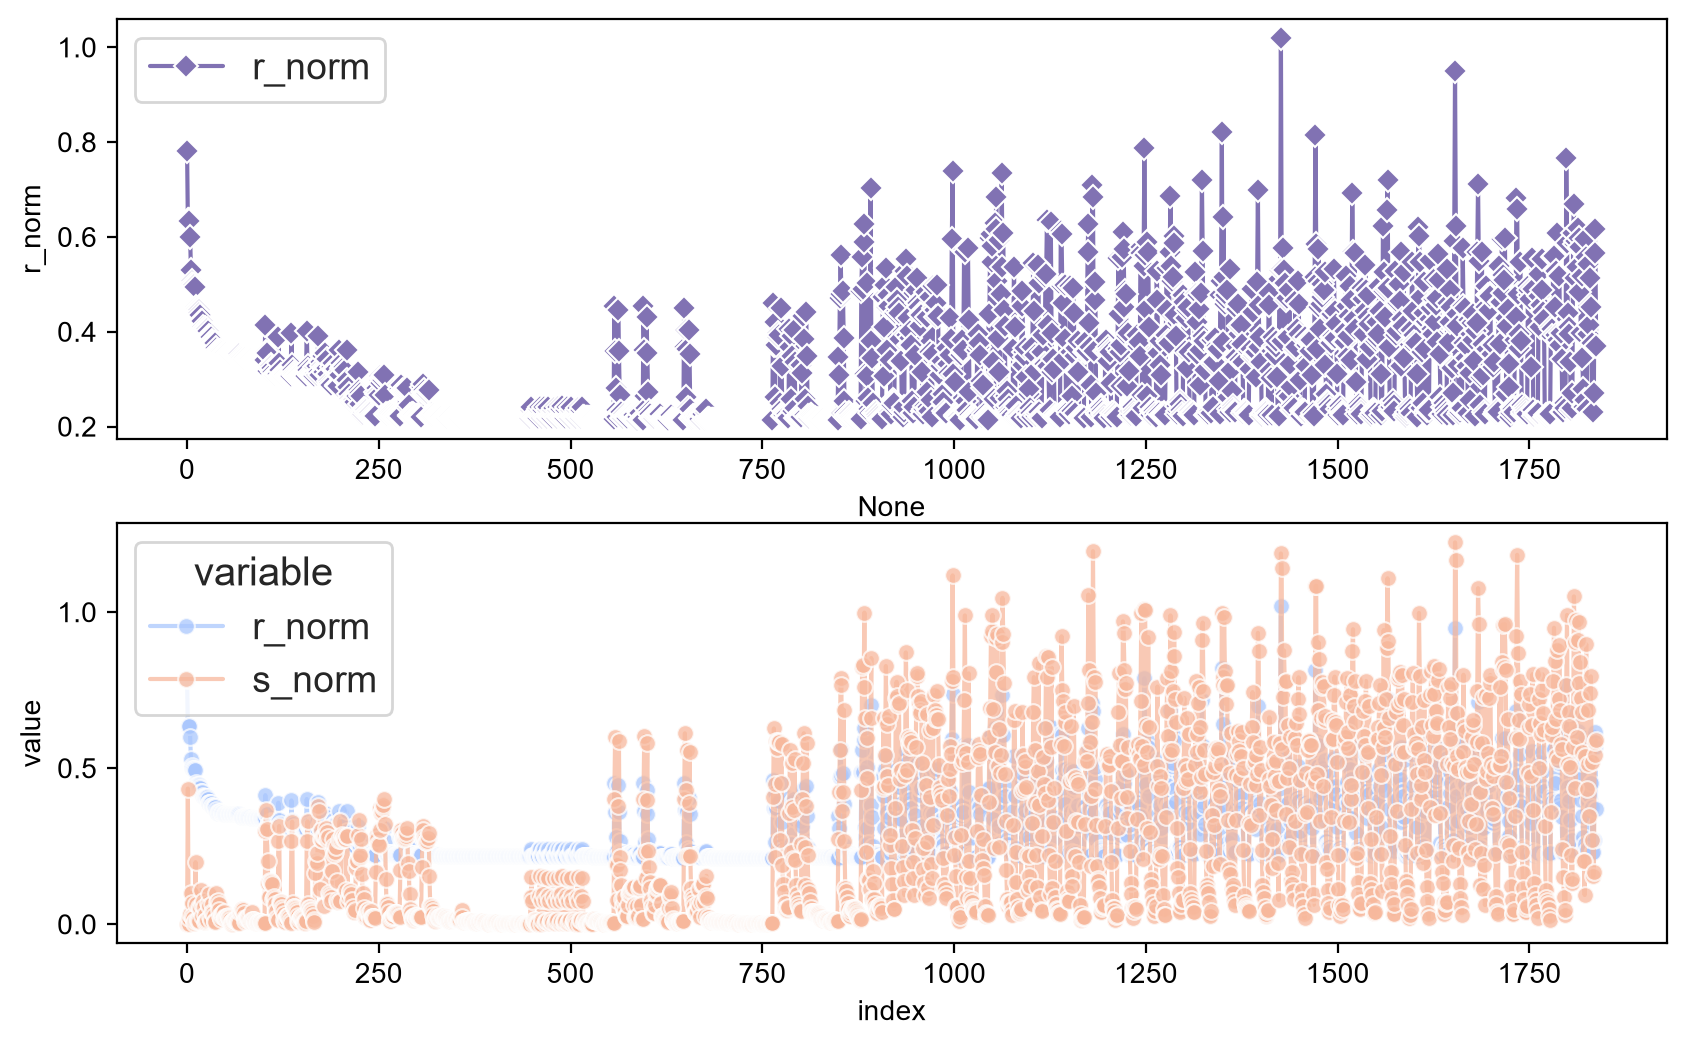

2026-08-19 16:58:29,297 - distributed.nanny - WARNING - Restarting worker (status=Status.running)
2026-08-19 16:58:29,355 - distributed.nanny - WARNING - Restarting worker (status=Status.running)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# df_reset = dfTimeLine['r_norm'].reset_index().melt(id_vars='index', var_name='Column', value_name='Value')
df_reset = dfTimeLine.reset_index().melt(id_vars=dfTimeLine.index.name or "index")
fig, axes = plt.subplots(2,1,dpi=200,figsize=(10, 6))
# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("coolwarm", n_colors=len(dfTimeLine.columns))

# plt.figure(figsize=(10, 6))
sns.lineplot(data=df_reset,
             x=df_reset.columns[0], y='value', hue='variable', marker='o', palette=palette, alpha=0.75, ax=axes[1])
sns.lineplot(data=dfTimeLine,y='r_norm', x=dfTimeLine.index, color='m', marker='D', label='r_norm', ax=axes[0])

# plt.ticklabel_format(useOffset=False, axis='y')
# plt.xlabel('Iterations')
# plt.ylabel('Delta-Gs')
# plt.title('ADMM Progress')
# plt.legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
# plt.tight_layout() 
# nama = "upward"
nama = "200iter_30bus"
plt.savefig(f"{nama}.png", dpi=400, bbox_inches='tight')

plt.show()

In [12]:
with open(f'{nama}.pkl', 'wb') as f:
    pickle.dump((xi_k,u_k), f)
# print(xi_k)

In [92]:
g={k:pyo.value(model_Q1.g[k]) for k in model_Q1.g}
eta0={k:pyo.value(model_Q1.eta0[k]) for k in model_Q1.eta0}
eta_ke={k:pyo.value(model_Q1.eta_ke[k]) for k in model_Q1.eta_ke}

xi_k = [i['xi_k'] for i in res2]
gk_hat = [i['xi_k'] for i in res2]
xk=[i['xk'] for i in res2]
zk=[i['zk'] for i in res2]
eta_kg=[i['eta_kg'] for i in res2]
# Saving variables to a file
with open(f'vars_{nama}.pkl', 'wb') as f:
    pickle.dump((g, xi_k, gk_hat, xk, zk, eta0, eta_ke, eta_kg), f)

In [ ]:
# np.random.seed(1234)

model_Q1 = ADMM1(case)
# model_Q2 = ADMM2_k(case)
solver1 = pyo.SolverFactory('gurobi')   
# solver2 = pyo.SolverFactory('gurobi')   
dfTimeLine = pd.DataFrame([], columns=['base'])
# rho = case['rho_ADMM']
rho = 0.1


is_import = False
with open('2300_73bus.pkl', 'rb') as f:
    is_import = True
    xi, u = pickle.load(f)

if is_import:
    for k in model_Q1.xi:
        model_Q1.xi[k] = xi[k]
        # model_Q2.zg[k] = zg[k]
        model_Q1.u[k] = u[k]
        # model_Q2.u[k] = model_Q1.u[k]
    
# for update-3
alpha = 0 # a step-size or acceleration parameter.
beta = 0.9  # momentum coefficient (in range [0, 1])

model_Q1.u_old = pyo.Param(model_Q1.G,  initialize=0.0,    mutable=True)   

for k in model_Q1.u:
    model_Q1.u_old[k] = model_Q1.u[k]
    
steps = 10
for i in range(1,steps+1):
    print(f"\n========== Iteration {i} START ==========")
    
    if i != 1:
        for k in model_Q1.G:
            model_Q1.xi[k].set_value(xi_avg[k])

    res1 = solver1.solve(model_Q1, tee=False)
    print("Solver Status 1:", res1.solver.status)
    print("Termination Condition 1:", res1.solver.termination_condition)
    obj_val = pyo.value(model_Q1.obj[1])
    print("Objective Value:", obj_val)

    # for k in model_Q1.G:
    #     model_Q2.zg[k].set_value(pyo.value(model_Q1.g[k]))
    zg_vals = {i: pyo.value(model_Q1.g[i]) for i in model_Q1.G}
    u_vals = {i:pyo.value(model_Q1.u[i]) for i in model_Q1.G}
    # tasks = [delayed(solve_one_k)(case, k, zg_vals, u_vals) for k in case["Kg"]]
    tasks = [
                delayed(solve_one_k)(case, k, zg_vals, u_k[idx, :])
                for idx, k in enumerate(case["Kg"])
            ]

    res2 = compute(*tasks, scheduler="processes")
    xi_k = np.array([i['xi_k'] for i in res2])
    xi_avg = np.mean(xi_k, axis=0)

    # res2 = solver2.solve(model_Q2, tee=False)
    # print("Solver Status 2:", res2.solver.status)
    # print("Termination Condition 2:", res2.solver.termination_condition)
    # obj_val = pyo.value(model_Q2.obj[1])
    # print("Objective Value:", obj_val)

    alpha = (i / (i + 3))
    # terminate, out = update(model_Q1,model_Q2, rho, verbose=False)
    # terminate, out = update_2(model_Q1,model_Q2, rho, verbose=False)
    terminate, out = update_3(model_Q1, xi_avg , rho, alpha, beta, verbose=False)
    
    
    dfTimeLine.loc[len(dfTimeLine),:] = out
    # dfTimeLine_obj.loc[len(dfTimeLine_obj),:] = (pyo.value(model_Q1.obj[1]), pyo.value(model_Q2.obj[1]))

    if terminate:
        print('MODELS CONVERGED!')
        break
        

    print(f"========== Iteration {i} END ========== diff:{out} \n")

Python loop time: 9.005806922912598


In [ ]:
# read and update
def get_z_v(model_Q1,xi_avg):
    g_vals = np.array([pyo.value(model_Q1.g[i]) for i in model_Q1.G])
    delta_g = (g_vals-xi_avg)
    zg=0.5*(g_vals + xi_avg)
    return zg, delta_g

def update_3(model_Q1, xi_avg, rho, alpha, beta, tol=1e-5, verbose=False):
    zg, delta_g = get_z_v(model_Q1,xi_avg)
    chk1 = np.linalg.norm(delta_g)
    cond1 = chk1 <= tol
    out = np.array(chk1)
    
    if (not cond1):
        u_prev = [model_Q1.u[i].value for i in model_Q1.G]
        u_prevprev = [model_Q1.u_old[i].value for i in model_Q1.G]
        for i in model_Q1.G:
            model_Q1.u[i] = u_prev[i] + rho*delta_g[i] + alpha*(1 - beta) *(u_prev[i] - u_prevprev[i])
            # model_Q1.u[i] = u_prev[i] + rho*delta_g[i]
            model_Q1.u_old[i] = u_prev[i]

        if verbose:
            print(out)
            
        return False, out
    
    else:
        return True, out
    
# def solve_one_k(case, k, zg_vals, u_vals):
#     model = ADMM2_k(case, k)

#     # set zg inside the worker
#     for i, val in zg_vals.items():
#         model.zg[i].set_value(float(val))
#     for i, val in u_vals.items():
#         model.u[i].set_value(float(val))

#     solver = pyo.SolverFactory("gurobi")
#     solver.options["Threads"] = 1
#     res = solver.solve(model, tee=False)
    
#     return {
#         "k": k,
#         "status": str(res.solver.status),
#         "term": str(res.solver.termination_condition),
#         "obj": pyo.value(model.obj[1]),
#         "xi_k": ([pyo.value(model.xi[idx]) for idx in model.xi]),
#         "xi_k_dict": ({idx:pyo.value(model.xi[idx]) for idx in model.xi}),
#         "gk_hat": ({idx:pyo.value(model.gk[idx]) for idx in model.gk}),
#         "xk": ({idx:model.xk[idx].value for idx in model.xk}),
#         "zk": ({idx:model.zk[idx].value for idx in model.zk}),
#         "eta_kg": ([pyo.value(model.eta_kg[idx]) for idx in model.eta_kg]),
#     }
    

def solve_one_k(case, k, zg_vals, u_vec):
    model = ADMM2_k(case, k)

    # set zg inside the worker (dict {i:val} is fine)
    for i, val in zg_vals.items():
        model.zg[i].set_value(float(val))

    # set worker-specific u (u_vec is array-like, indexed by generator i)
    for i in model.G:
        model.u[i].set_value(float(u_vec[i]))

    solver = pyo.SolverFactory("gurobi")
    solver.options["Threads"] = 1
    res = solver.solve(model, tee=False)

    return {
        "k": k,
        "status": str(res.solver.status),
        "term": str(res.solver.termination_condition),
        "obj": pyo.value(model.obj[1]),
        "xi_k": [pyo.value(model.xi[k, i]) for i in model.G],  # ordered vector length ngen
        "xi_k_dict": {(k, i): pyo.value(model.xi[k, i]) for i in model.G},
        "gk_hat": {(k, i): pyo.value(model.gk[k, i]) for i in model.G},
        "xk": {(k, i): model.xk[k, i].value for i in model.G},
        "zk": {i: model.zk[i].value for i in model.G},
        "eta_kg": [pyo.value(model.eta_kg[k, b]) for b in model.BR],
    }
